Importing the required packages

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Source data/prepocessed.csv")
df

,month,day,order,country,page1_main_category,colour,location,model_photography,price,price_2,page,total_clicks,browsing_depth,weekday,weekend
0,6,22,21,29,3,13,1,2,48,1,2,84,4,6,1
1,5,19,6,29,2,13,3,1,57,1,2,9,2,0,0
2,7,15,2,29,3,9,5,1,48,1,1,10,3,1,0
3,5,2,2,29,2,2,4,1,43,2,1,6,2,4,0
4,6,9,16,29,2,9,5,1,57,1,2,15,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132374,7,4,3,29,4,2,1,1,48,1,2,5,5,4,0
132375,6,19,9,29,3,14,3,1,28,2,2,33,5,3,0
132376,7,15,4,29,1,3,2,2,38,2,1,8,1,1,0
132377,7,28,16,29,3,9,5,2,20,2,3,18,4,0,0



🔹 Training Logistic Regression...

🔹 Training Decision Tree...

🔹 Training Random Forest...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(



🔹 Training XGBoost...

🔹 Training Neural Network (MLP)...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [21:35:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 Evaluation Results:

                      Accuracy Precision    Recall  F1 Score   ROC AUC
Logistic Regression   0.993201   0.99693  0.989107  0.993003  0.905673
Decision Tree              1.0       1.0       1.0       1.0       1.0
Random Forest         0.994511  0.995293  0.993443  0.994368  0.999792
XGBoost                    1.0       1.0       1.0       1.0       1.0
Neural Network (MLP)       1.0       1.0       1.0       1.0  0.534331


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


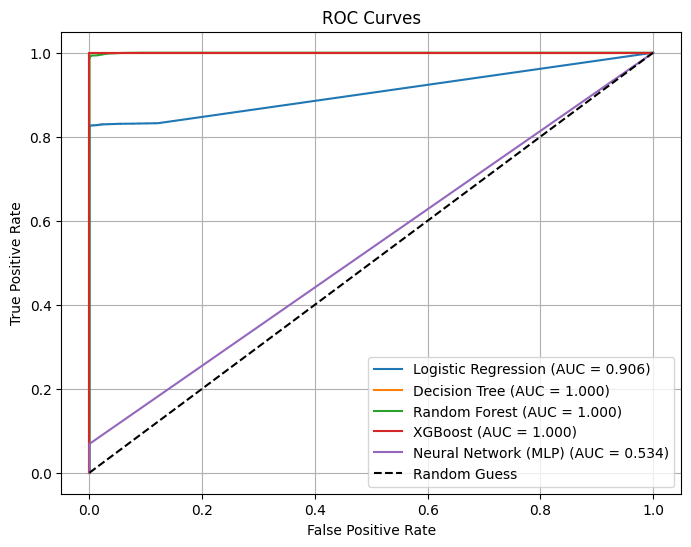

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assume df is your DataFrame already loaded, e.g.
# df = pd.read_csv("your_data.csv")

X = df.drop('price_2', axis=1)
y = df['price_2']

# Encode target labels to 0 and 1 (important for classification metrics and XGBoost)
le = LabelEncoder()
y = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define models with pipelines
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Decision Tree": Pipeline([
        # No scaler needed for tree-based models
        ("model", DecisionTreeClassifier(max_depth=6, min_samples_split=4, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(n_estimators=60, max_depth=6, min_samples_split=4, random_state=42))
    ]),
    "XGBoost": Pipeline([
        ("model", XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
    ]),
    "Neural Network (MLP)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42))
    ])
}

results_test = {}

for name, pipeline in models.items():
    print(f"\n🔹 Training {name}...")

    pipeline.fit(X_train, y_train)

    y_pred_test = pipeline.predict(X_test)

    model = pipeline.named_steps["model"]
    # Check if model supports predict_proba
    if hasattr(model, "predict_proba"):
        y_proba_test = model.predict_proba(X_test)[:, 1]
    else:
        # Use decision_function if predict_proba not available, else fallback to predictions
        if hasattr(model, "decision_function"):
            y_scores = model.decision_function(X_test)
            # If binary, convert to probabilities via sigmoid approximation
            from scipy.special import expit
            y_proba_test = expit(y_scores)
        else:
            y_proba_test = None

    acc = accuracy_score(y_test, y_pred_test)
    prec = precision_score(y_test, y_pred_test)
    rec = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    roc_auc = roc_auc_score(y_test, y_proba_test) if y_proba_test is not None else None
    cm = confusion_matrix(y_test, y_pred_test)

    results_test[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC AUC": roc_auc,
        "Confusion Matrix": cm
    }

# Convert to DataFrame for neat display (drop confusion matrix from table)
results_df = pd.DataFrame(results_test).T.drop(columns=['Confusion Matrix'])
print("\n📊 Evaluation Results:\n")
print(results_df.round(3))

# Optional: Plot ROC curves for all models that have probabilities
plt.figure(figsize=(8, 6))
for name, pipeline in models.items():
    model = pipeline.named_steps["model"]
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
        from scipy.special import expit
        y_proba = expit(y_scores)
    else:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.grid()
plt.show()


In [4]:
import pickle

# Extract the decision tree pipeline
decision_tree_pipeline = models["Decision Tree"]

# Save (pickle) the model to a file
with open("decision_tree_model.pkl", "wb") as file:
    pickle.dump(decision_tree_pipeline, file)

print("✅ Decision Tree pipeline pickled as 'decision_tree_model.pkl'")


✅ Decision Tree pipeline pickled as 'decision_tree_model.pkl'


In [5]:
with open("decision_tree_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
test_preds = loaded_model.predict(X_test)
# Show sample predictions
print("\n📌 Sample Predictions on Test Data:", test_preds[:10])

print("\n📌 Original Predictions on Test Data:", y_test[:10])



📌 Sample Predictions on Test Data: [0 0 0 1 0 1 1 1 0 1]

📌 Original Predictions on Test Data: [0 0 0 1 0 1 1 1 0 1]


Test data analysis

In [6]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# ---------- Load and preprocess test data ----------
test_df = pd.read_csv("Source data/test_data.csv")

# Feature engineering
total_clicks_test = test_df.groupby('session_id')['order'].count().reset_index()
total_clicks_test.rename(columns={'order': 'total_clicks'}, inplace=True)

browsing_depth_test = test_df.groupby('session_id')['page'].max().reset_index()
browsing_depth_test.rename(columns={'page': 'browsing_depth'}, inplace=True)

df1_test = total_clicks_test.merge(browsing_depth_test, on='session_id')
test_df = test_df.merge(df1_test, on='session_id')

test_df['weekday'] = pd.to_datetime(test_df[['year', 'month', 'day']]).dt.dayofweek
test_df['weekend'] = (test_df['weekday'] >= 5).astype(int)

test_df = test_df.drop(columns=['year', 'session_id', 'page2_clothing_model'])

# Save preprocessed test data
test_df.to_csv("Source data/preprocessed_test.csv", index=False)

# ---------- Load and preprocess training data ----------
df = pd.read_csv("Source data/preprocessed_test.csv")


# ---------- Train/test split ----------
X = df.drop('price_2', axis=1)
y = df['price_2']

# Encode target labels to 0 and 1 (important for classification metrics and XGBoost)
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ---------- Load pickled model ----------
with open("decision_tree_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

# ---------- Predict on new test data ----------
test_preds = loaded_model.predict(X)

# Show sample predictions
print("\n📌 Sample Predictions on Test Data:", test_preds[:10])

# ---------- Evaluate model on hold-out validation set ----------
y_pred_test = loaded_model.predict(X_test)
y_proba_test = loaded_model.predict_proba(X_test)[:, 1] if hasattr(loaded_model, "predict_proba") else None

# Compute evaluation metrics
acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, average='binary')
rec = recall_score(y_test, y_pred_test, average='binary')
f1 = f1_score(y_test, y_pred_test, average='binary')
roc_auc = roc_auc_score(y_test, y_proba_test) if y_proba_test is not None else None
cm = confusion_matrix(y_test, y_pred_test)

# Save and display results
results_test = {
    "Decision Tree": {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC AUC": roc_auc,
        "Confusion Matrix": cm
    }
}

results_df = pd.DataFrame(results_test).T.drop(columns=['Confusion Matrix'])
print("\n📊 Evaluation Results:\n")
print(results_df)



📌 Sample Predictions on Test Data: [1 1 1 0 1 1 1 1 1 0]

📊 Evaluation Results:

              Accuracy Precision Recall F1 Score ROC AUC
Decision Tree      1.0       1.0    1.0      1.0     1.0
